In [ ]:
# YF
# 7/21/25
# cleanup  - get working within VSCode
%pip install numpy
%pip install matplotlib
%pip install mplcursors
%pip install ipympl
%pip install plotly.express
%pip install nbformat nbclient


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 4/8 [jsonschema-specifications]
   ------------------------------ --------- 6/8 [nbformat]
   ---------------------------------------- 8/8 [nbclient]

Note: 

In [2]:
import DiamondCalcAll as dca 
import numpy as np
import matplotlib.pyplot as plt



In [3]:
from enum import Enum
class Action(Enum):
    eShowTransmission = 1
    eShowAbsorption  = 2


1000.0, 1.00e+00
1200.0, 1.00e+00
1400.0, 9.98e-01
1600.0, 9.80e-01
1800.0, 9.45e-01
2000.0, 8.50e-01
2200.0, 8.05e-01
2400.0, 7.45e-01
2600.0, 6.67e-01
2800.0, 5.65e-01
3000.0, 4.31e-01
3200.0, 3.93e-01
3400.0, 3.51e-01
3600.0, 3.07e-01
3800.0, 2.60e-01
4000.0, 2.09e-01
4200.0, 1.90e-01
4400.0, 1.71e-01
4600.0, 1.52e-01
4800.0, 1.31e-01
5000.0, 1.11e-01
5200.0, 1.02e-01
5400.0, 9.25e-02
5600.0, 8.32e-02
5800.0, 7.38e-02
6000.0, 6.42e-02
6200.0, 6.05e-02
6400.0, 5.68e-02
6600.0, 5.30e-02
6800.0, 4.93e-02
7000.0, 4.55e-02
7200.0, 4.17e-02
7400.0, 3.79e-02
7600.0, 3.41e-02
7800.0, 3.02e-02
8000.0, 2.64e-02
8200.0, 2.50e-02
8400.0, 2.37e-02
8600.0, 2.24e-02
8800.0, 2.10e-02
9000.0, 1.97e-02
9200.0, 1.84e-02
9400.0, 1.70e-02
9600.0, 1.57e-02
9800.0, 1.44e-02
10000.0, 1.30e-02
10200.0, 1.26e-02
10400.0, 1.23e-02
10600.0, 1.19e-02
10800.0, 1.15e-02
11000.0, 1.11e-02
11200.0, 1.07e-02
11400.0, 1.04e-02
11600.0, 9.99e-03
11800.0, 9.61e-03
12000.0, 9.23e-03
12200.0, 8.85e-03
12400.0, 8.47e-03
1

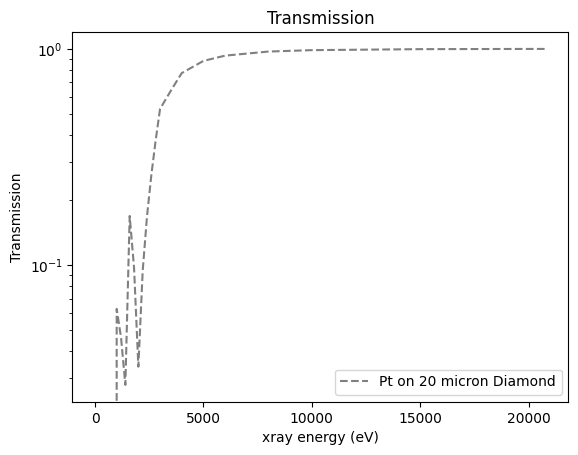

In [101]:
import plotly.express as px
import plotly.graph_objects as go


#diamon_thick40 = 40
#diamon_thick20 = 20
#diamon_thick10 = 10
#Pt_metal_thick = 30
#Al_metal_thick = 100


if 0:
    # Values for IDNET 7/22/25
    diamond_thick = 45
    flux_min = 1e10  # Flux in photons/s 
    flux_max = 2e15  
    max_energy = 100 # in keV
    coating ="Pt"
    metal_thick = 30

# Values for MAXIV 7/22/25
diamond_thick = 20
flux_min = 1e12  # Flux in photons/s 
flux_max = 1e15  
max_energy = 20 # in keV
coating = "Al"
metal_thick = 100


flux = flux_max

energy_graph = 0
xyzcurve = 0
xyzcurve2 = 0
#al45curve = 0
#al20curve = 0
EoffSet = 1000   # offset from 0 to start 

NPoints = 100
#showme = Action.eShowAbsorption
showme = Action.eShowTransmission
use_px_interactive = False   # Interactive is nice but ugly. Set to false for prettier curves




# for val in range (100):
#     energy = (val +1) * 100 + EoffSet
#     al45 = dca.MAdevice_perf_al (diamon_thick45, Al_metal_thick, energy, flux)
#     transDev = 1-(al45[2] + al45[3])
#     al45curve = np.append(al45curve,np.absolute(transDev))
for val in range (NPoints): # number of steps 
    #energy = (val +1) * 100 + EoffSet   # number of steps *100 is the max E on your plot
    energy = (val / NPoints) * max_energy*1000 +  EoffSet   # number of steps *100 is the max E on your plot
    if coating == "Pt":
        xyz = dca.MAdevice_perf_pt (diamond_thick, metal_thick,energy, 1) # flux DontCare
    elif coating == "Al":    
        xyz = dca.MAdevice_perf_al (diamond_thick, metal_thick,energy, 1) # flux DontCare
    
    ##
    print(f"{energy:.1f}, {xyz[3]:.2e}")
    ##
    
    if showme == Action.eShowTransmission:
        transDev = 1-(xyz[2]+xyz[3])
        plotTitle = "Transmission"
    elif  showme == Action.eShowAbsorption:
        transDev = xyz[3]  # [3] is Carbon Absorption
        plotTitle = "Absorption"
        
    xyzcurve = np.append(xyzcurve,np.absolute(transDev))
    #####
    xyzcurve20 = dca.MAdevice_perf_pt (20, metal_thick,energy, 1)    # flux DontCare
    if showme == Action.eShowTransmission:
        transDev = 1-(xyzcurve20[2]+xyzcurve20[3])
    elif  showme == Action.eShowAbsorption:
        transDev = xyzcurve20[3]  # [3] is Carbon Absorption
    
    pt20curve = np.append(pt20curve,np.absolute(transDev))
    ######
    energy_graph = np.append(energy_graph,energy)



 
if use_px_interactive:
    # First curve
    fig = go.Figure()

    fig.add_scatter(
        x=energy_graph[1:],
        y=xyzcurve[1:],
        mode='markers',
        marker=dict(size=3, color='black'),
        name=f'Pt on {diamond_thick} micron Diamond',
        showlegend=True
    )

    # Add second scatter for pt25curve
    fig.add_scatter(
        x=energy_graph[1:], 
        y=xyzcurve2[1:], 
        mode='markers',
        marker=dict(size=3, color='red'),
        name="Pt on 25 micron Diamond"
    )

    fig.update_layout(
        title=plotTitle,
        yaxis_type="log"
    )

    fig.update_yaxes(
        exponentformat='e',   # 'e' for 1e+6, 'power' for 10^6
        showexponent='all'    # Show exponent on all ticks
    )
    fig.show()

else:
    plt.plot(energy_graph, xyzcurve, label = f"Pt on {diamond_thick} micron Diamond", color="gray", linestyle = "--")
    plt.title(plotTitle)
    plt.legend()
    plt.xlabel("xray energy (eV)")
    plt.ylabel(plotTitle)
    plt.yscale('log')
    


Flux 1.00e+15, Diamond Thick 20
Energy, Current, Heat
0) 1000.0, 4.71e-03, 3.05e-01
1) 1200.0, 6.97e-03, 3.62e-01
2) 1400.0, 1.00e-02, 4.16e-01
3) 1600.0, 1.30e-02, 4.64e-01
4) 1800.0, 1.52e-02, 5.05e-01
5) 2000.0, 1.64e-02, 5.12e-01
6) 2200.0, 1.33e-02, 5.77e-01
7) 2400.0, 1.28e-02, 6.12e-01
8) 2600.0, 1.29e-02, 6.22e-01
9) 2800.0, 1.17e-02, 6.21e-01
10) 3000.0, 1.04e-02, 5.66e-01
11) 3200.0, 1.05e-02, 5.64e-01
12) 3400.0, 1.03e-02, 5.56e-01
13) 3600.0, 9.86e-03, 5.34e-01
14) 3800.0, 9.15e-03, 4.99e-01
15) 4000.0, 8.06e-03, 4.51e-01
16) 4200.0, 7.85e-03, 4.39e-01
17) 4400.0, 7.54e-03, 4.21e-01
18) 4600.0, 7.12e-03, 3.99e-01
19) 4800.0, 6.57e-03, 3.71e-01
20) 5000.0, 5.89e-03, 3.38e-01
21) 5200.0, 5.67e-03, 3.26e-01
22) 5400.0, 5.41e-03, 3.13e-01
23) 5600.0, 5.09e-03, 2.97e-01
24) 5800.0, 4.72e-03, 2.78e-01
25) 6000.0, 4.30e-03, 2.57e-01
26) 6200.0, 4.20e-03, 2.52e-01
27) 6400.0, 4.09e-03, 2.46e-01
28) 6600.0, 3.95e-03, 2.38e-01
29) 6800.0, 3.80e-03, 2.30e-01
30) 7000.0, 3.63e-03, 2.21

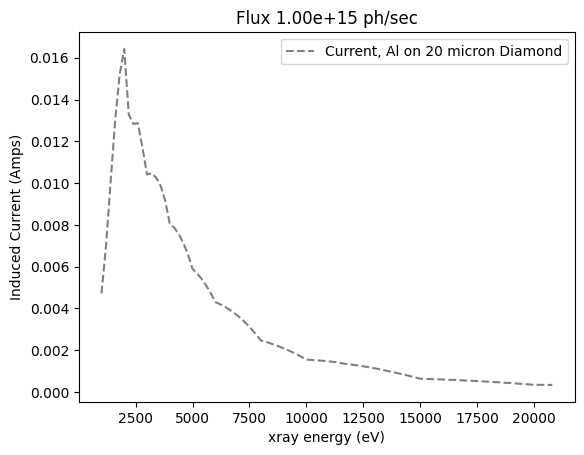

In [103]:
# PLOT Current & Heat Load

cur = []
energylist = []
heatlist = []

for j,val in enumerate(range (NPoints)): # number of steps 
    #energy = (val +1) * 100 + EoffSet   # number of steps *100 is the max E on your plot
    energy =  (val / NPoints) * max_energy*1000 +  EoffSet   # number of steps *100 is the max E on your plot
    pt45 = dca.MAdevice_perf_pt (diamond_thick, metal_thick,energy, flux_max)
    
    cur.append( pt45[0])
    heatlist.append(pt45[1])
    energylist.append(energy)
    ##
    if (j==0):
        print(f"Flux {flux_max:.2e}, Diamond Thick {diamond_thick}")
        print(f"Energy, Current, Heat")
        
        
    print(f"{j}) {energy:.1f}, {pt45[0]:.2e}, {pt45[1]:.2e}")
    ##
    
pt45curve = np.array(cur) # more efficient
energy_graph = np.array(energylist)
heat_graph = np.array(heatlist)

plt.plot( energy_graph, pt45curve, label = f"Current, {coating} on {diamond_thick} micron Diamond", color="gray", linestyle = "--")
plt.xlabel("xray energy (eV)")
plt.ylabel("Induced Current (Amps)")
plt.title(f"Flux {flux:.2e} ph/sec") 
plt.legend()
plt.show()


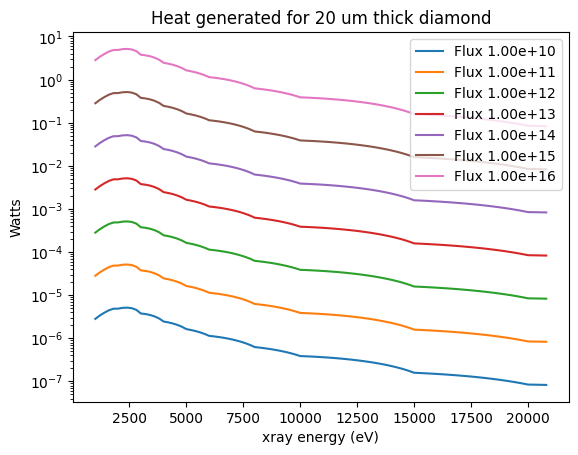

In [106]:
fluxes = [1e10, 1e11, 1e12, 1e13, 1e14, 1e15, 1e16]

for flux in fluxes:
    cur = []
    heatlist = []
    energylist = []
    for j,val in enumerate(range (NPoints)): # number of steps 
        #energy = (val +1) * 100 + EoffSet   # number of steps *100 is the max E on your plot
        energy =  (val / NPoints) * max_energy*1000 +  EoffSet   # number of steps *100 is the max E on your plot
        
        
        if coating == "Pt":
            xyz = dca.MAdevice_perf_pt (diamond_thick, metal_thick,energy, flux) 
        elif coating == "Al":    
            xyz = dca.MAdevice_perf_al (diamond_thick, metal_thick,energy, flux) 
        
        cur.append( xyz[0])
        heatlist.append(xyz[1])
        energylist.append(energy)
    
    pt45curve = np.array(cur) # more efficient
    energy_graph = np.array(energylist)
    heat_graph = np.array(heatlist)

    plt.plot( energy_graph, heat_graph, label = f"Flux {flux:.2e}" )
    
plt.xlabel("xray energy (eV)")
plt.ylabel("Watts")
plt.title(f"Heat generated for {diamond_thick} um thick diamond") 
plt.legend()
plt.yscale('log')
plt.show()

C:\Users\yoram\AppData\Local\Temp\ipykernel_54224\1387526983.py:29: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



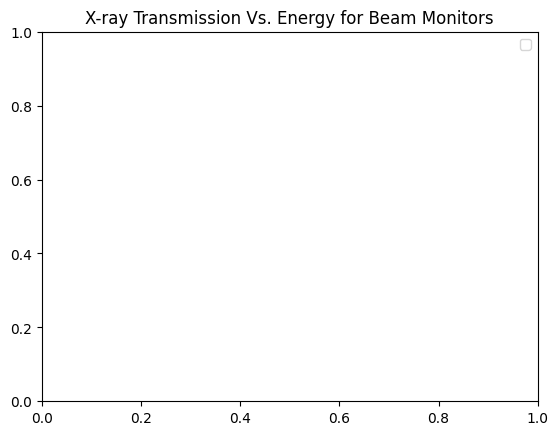

In [9]:
pt10curve = 0

if 0:
    for val in range (100):   # number of steps 
        energy = (val +1) * 100 + EoffSet   # gives you up to 30,000 eV 
        pt20 = dca.MAdevice_perf_pt (diamon_thick20, Pt_metal_thick, energy, flux)
        transDev = 1-(pt20[2]+ pt20[3])
        pt20curve = np.append(pt20curve,np.absolute(transDev))
    plt.plot(energy_graph[1:],pt20curve[1:], label = "Pt 20 micron Diamond", color="gray", linestyle = "--")

    for val in range (100):
        energy = (val +1) * 100 + EoffSet
        al45 = dca.MAdevice_perf_al (diamon_thick45, Al_metal_thick, energy, flux)
        transDev = 1-(al45[2]+ al45[3])
        al45curve = np.append(al45curve,np.absolute(transDev))
    plt.plot(energy_graph[1:], al45curve[1:], label = "Al 45 micron Diamond")    

    for val in range (100):
        energy = (val +1) * 100 + EoffSet
        al20 = dca.MAdevice_perf_al (diamon_thick20, Al_metal_thick, energy, flux)
        transDev = 1-(al20[2] + al20[3])
        al20curve = np.append(al20curve,np.absolute(transDev))
    plt.plot(energy_graph[1:],al20curve[1:], label = "Al 20 micron Diamond", color="green", linestyle = "--")    

#print(pt45curve)


plt.title("X-ray Transmission Vs. Energy for Beam Monitors")
plt.legend()
plt.savefig("Scratch\\DiamondCurve.png")
plt.show()

In [ ]:
plt.plot(energy_graph[1:], al45curve[1:], label = "Al 45 micron Diamond")
plt.plot(energy_graph[1:],al10curve[1:], label = "Al 10 micron Diamond")
plt.title("X-ray Transmission Vs. Energy for Beam Monitors")
plt.legend()
plt.show()

In [ ]:
# For APS for Rick 05/22/2023 

diamon_thick45 = 45 # in um 

Pt_metal_thick = 30 # in nm 


flux = 1
energy_graph = 0
pt45curve = 0
EoffSet = 4000   # offset from 0 to start 
for val in range (300): # number of steps 
    energy = (val +1) * 100 + EoffSet   # number of steps *100 is the max E on your plot
    pt45 = dca.MAdevice_perf_pt (diamon_thick45, Pt_metal_thick,energy, flux)
    transDev = 1-(pt45[2]+pt45[3])
    pt45curve = np.append(pt45curve,np.absolute(transDev))
    energy_graph = np.append(energy_graph,energy)

pt10curve = 0


plt.plot(energy_graph[1:], pt45curve[1:], label = "Pt 45 micron diamond",color="black")
plt.title("X-ray Transmission vs. Energy for Pt Diamond Beam Monitor")
plt.legend()
plt.xlabel('Energy (eV)')
plt.ylabel('Transmission')
plt.savefig("45nmPt_DiamondCurve.png")
plt.show()

In [ ]:
diamon_thick20 = 25
diamon_thick40 = 45
diamon_thick10 = 10
Pt_metal_thick = 30
Al_metal_thick = 100

flux = 1
energy_graph = 0
pt20curve = 0
pt45curve = 0
al45curve = 0
al20curve = 0
EoffSet = 2000   # offset from 0 to start 

for val in range (200): # number of steps 
    energy = (val +1) * 100 + EoffSet   # number of steps *100 is the max E on your plot
    pt20 = dca.MAdevice_perf_pt (diamon_thick20, Pt_metal_thick,energy, flux)
    transDev = 1-(pt20[2]+pt20[3])
    pt20curve = np.append(pt20curve,np.absolute(transDev))
    energy_graph = np.append(energy_graph,energy)

for val in range (200):   # number of steps 
    energy = (val +1) * 100 + EoffSet   # gives you up to 30,000 eV 
    pt45 = dca.MAdevice_perf_pt (diamon_thick45, Pt_metal_thick, energy, flux)
    transDev = 1-(pt45[2]+ pt45[3])
    pt45curve = np.append(pt45curve,np.absolute(transDev))

for val in range (200):
    energy = (val +1) * 100 + EoffSet
    al20 = dca.MAdevice_perf_al (diamon_thick20, Al_metal_thick, energy, flux)
    transDev = 1-(al20[2]+ al20[3])
    al20curve = np.append(al20curve,np.absolute(transDev))

for val in range (200):
    energy = (val +1) * 100 + EoffSet
    al45 = dca.MAdevice_perf_al (diamon_thick45, Al_metal_thick, energy, flux)
    transDev = 1-(al45[2] + al45[3])
    al45curve = np.append(al45curve,np.absolute(transDev))

#print(pt20curve)

plt.plot(energy_graph[1:], pt20curve[1:], label = "Pt 25 micron Diamond",color="black")
plt.plot(energy_graph[1:],pt45curve[1:], label = "Pt 45 micron Diamond", color="black", linestyle = "--")
plt.plot(energy_graph[1:], al20curve[1:], label = "Al 25 micron Diamond", color="green")
plt.plot(energy_graph[1:],al45curve[1:], label = "Al 45 micron Diamond", color="green", linestyle = "--")
plt.title("X-ray Transmission Vs. Energy for Diamond Beam Monitors")
plt.legend()
plt.savefig("C:\\Users\\valerief\\Documents\\GitHub\\Scratch\\DiamondCurve.png")
plt.show()